# Exploring the data 

Load in all of the data and rasters that we have from the previous step. 

We'll focus on just the lowman data for now. 

In [48]:
import numpy as np

import matplotlib.pyplot as plt
import xarray as xr
import rioxarray as rio
import seaborn as sns
import pandas as pd

In [35]:
data_dir = '../data/' # on local machine
data_file = 'stacks/mores_creek/'

data = xr.open_zarr(data_dir + data_file)
# drop crs data var
data = data.drop_vars('crs')
print(data)

<xarray.Dataset> Size: 862kB
Dimensions:       (y: 20, x: 26, pair: 45)
Coordinates:
  * y             (y) float64 160B 43.98 43.98 43.97 43.97 ... 43.92 43.91 43.91
  * x             (x) float64 208B -115.7 -115.7 -115.7 ... -115.6 -115.6 -115.6
  * pair          (pair) <U13 2kB '200131_200213' ... '210316_210322'
    band          int64 8B ...
    spatial_ref   int64 8B ...
Data variables: (12/13)
    aspect        (y, x) float32 2kB dask.array<chunksize=(20, 25), meta=np.ndarray>
    canopy_2019   (y, x) float32 2kB dask.array<chunksize=(20, 25), meta=np.ndarray>
    coherence     (pair, y, x) float32 94kB dask.array<chunksize=(45, 20, 25), meta=np.ndarray>
    cover_2019    (y, x) float64 4kB dask.array<chunksize=(20, 25), meta=np.ndarray>
    curve         (y, x) float32 2kB dask.array<chunksize=(20, 25), meta=np.ndarray>
    elevation     (y, x) float32 2kB dask.array<chunksize=(20, 25), meta=np.ndarray>
    ...            ...
    mean_temp     (pair, y, x) float64 187kB dask.arr

In [37]:
# nan mask 
nan_mask = np.isnan(data['coherence'].values).any(axis=0)  # axis=0 is the 'pair' dimension

# Now apply it universally to all variables
for var in data.data_vars:
    if 'x' in data[var].dims and 'y' in data[var].dims:
        data[var] = data[var].where(~nan_mask, drop=False)

Static variables: ['aspect', 'canopy_2019', 'cover_2019', 'curve', 'elevation', 'slope', 'snow_class']
Pair variables: ['coherence', 'max_temp', 'mean_temp', 'sd_change', 'swe_change', 'total_precip']


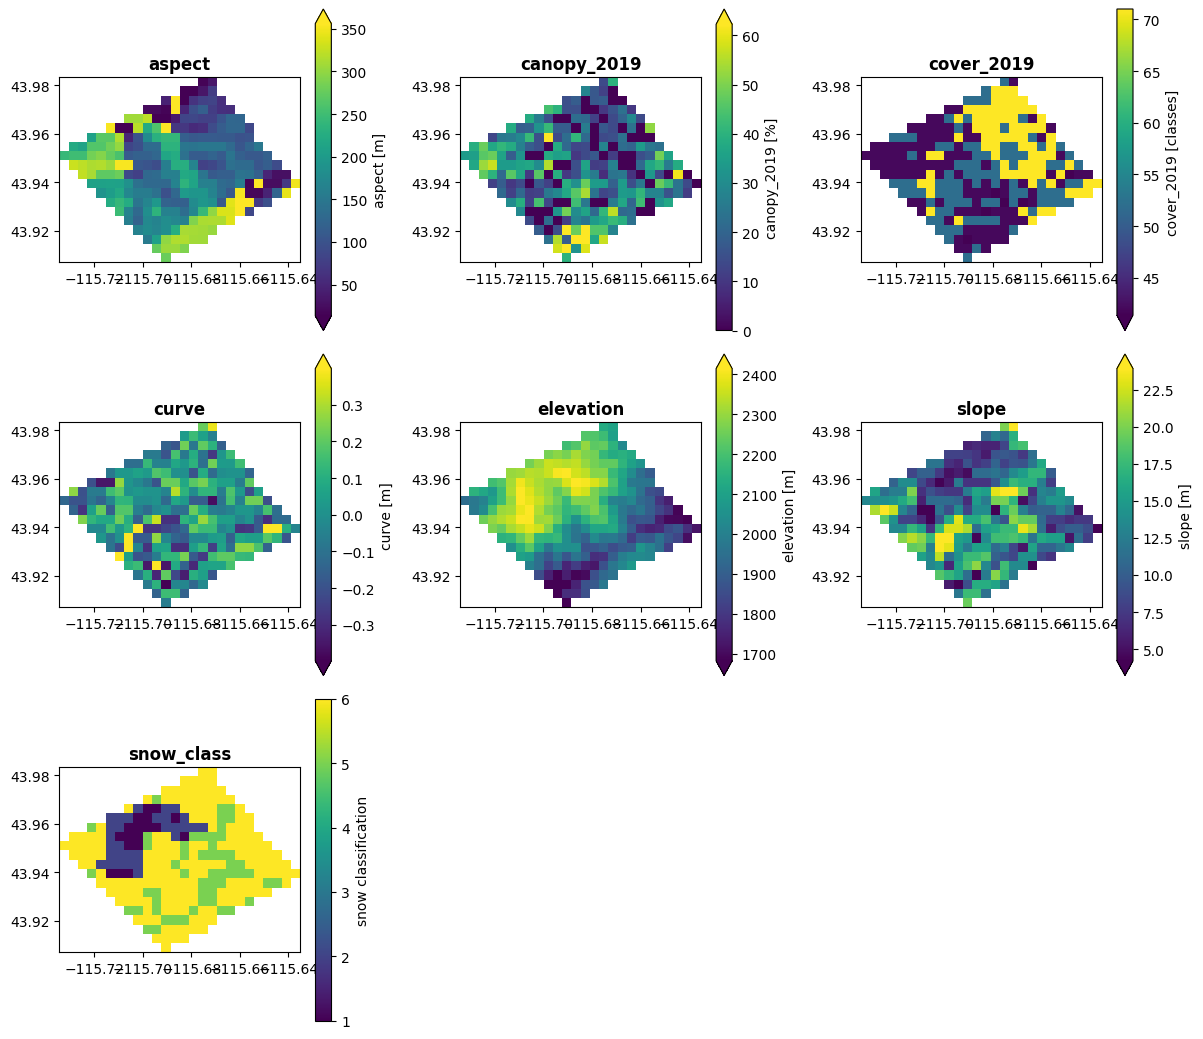

In [39]:
static_vars = [var for var in data.data_vars if 'pair' not in data[var].dims]
print("Static variables:", static_vars)
pair_vars = [var for var in data.data_vars if 'pair' in data[var].dims]
print("Pair variables:", pair_vars)

# ==========================================
# 2. PLOT STATIC VARIABLES (Single Dashboard)
# ==========================================
n_static = len(static_vars)
cols = 3
rows = int(np.ceil(n_static / cols))

fig_static, axes_static = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
axes_static = axes_static.flatten()

for i, var in enumerate(static_vars):
    ax = axes_static[i]
    
    # robust=True drops top/bottom 2% of extreme values for a prettier color stretch
    data[var].plot(ax=ax, robust=True, cmap='viridis') 
    
    ax.set_title(var, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_aspect('equal') # Keeps pixels square since this is spatial data

# Hide any empty subplots if n_static doesn't divide perfectly by 3
for j in range(i + 1, len(axes_static)):
    axes_static[j].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
# 3. Flatten into ML-ready format
data_array = data.to_array(dim='variable')  # (variable, pair, x, y)
data_2d = data_array.values.reshape(data_array.shape[0], -1).T  # (n_samples, n_features)

# 4. Remove any remaining NaNs for correlation/ML
data_clean = data_2d[~np.isnan(data_2d).any(axis=1)]

# 5. Correlation matrix
corr_matrix = pd.DataFrame(data_clean, 
                           columns=[v for v in data.data_vars]).corr()
corr_matrix.style.background_gradient(cmap='coolwarm')

,aspect,canopy_2019,coherence,cover_2019,curve,elevation,max_temp,mean_temp,sd_change,slope,snow_class,swe_change,total_precip
aspect,1.000000,0.374624,-0.106142,-0.369402,0.001067,-0.018959,-0.033607,0.010160,-0.065081,0.043254,-0.068654,-0.033398,-0.001187
canopy_2019,0.374624,1.000000,-0.069325,-0.563448,-0.061295,-0.203450,-0.043456,-0.012673,0.027919,0.022210,0.067658,0.032100,-0.008849
coherence,-0.106142,-0.069325,1.000000,0.081780,0.023582,0.099557,-0.429534,-0.191606,-0.007313,-0.009167,-0.052045,-0.048642,-0.411702
cover_2019,-0.369402,-0.563448,0.081780,1.000000,0.150604,0.130939,0.052447,-0.002793,-0.008795,-0.036577,-0.003863,-0.011739,0.004201
curve,0.001067,-0.061295,0.023582,0.150604,1.000000,0.284723,0.006990,0.000415,-0.028570,-0.023143,-0.142857,-0.017399,0.001098
elevation,-0.018959,-0.203450,0.099557,0.130939,0.284723,1.000000,0.064199,0.109317,-0.082068,-0.117944,-0.572270,-0.025767,0.044947
max_temp,-0.033607,-0.043456,-0.429534,0.052447,0.006990,0.064199,1.000000,0.195798,-0.031518,-0.007290,-0.014523,-0.171094,0.900384
mean_temp,0.010160,-0.012673,-0.191606,-0.002793,0.000415,0.109317,0.195798,1.000000,0.397181,-0.008024,-0.060209,0.262805,0.115435
sd_change,-0.065081,0.027919,-0.007313,-0.008795,-0.028570,-0.082068,-0.031518,0.397181,1.000000,0.040026,0.074279,0.834165,-0.067919
slope,0.043254,0.022210,-0.009167,-0.036577,-0.023143,-0.117944,-0.007290,-0.008024,0.040026,1.000000,0.303189,0.041187,-0.004881


In [ ]:
# map the extent of the flights on satellite imagery 


Physical terrain parameters 

In [ ]:
# plot the DEM 

In [ ]:
# plot all other features 